<a href="https://colab.research.google.com/github/Hania-Emaan/urdu-ocr-codesaviours-si26-Hania-/blob/main/SI26_Week1_Hania.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 1.What is OCR (Optical Character Recognition)?

 OCR is a technology that allows computers to read text from images, scanned documents, or photographs and convert it into digital, editable text. It works by analyzing the shapes and patterns of characters in an image and matching them to known letters or symbols. This is what allows you to scan a printed page and turn it into a Word document, or search for text within a scanned PDF.

2.Why is Urdu OCR harder than English OCR?

 Urdu is written in a cursive script where letters change shape depending on their position in a word (beginning, middle, or end), unlike English letters which stay mostly the same. Urdu also has no fixed baseline, meaning letters can appear above, below, or connected to each other in flowing, non-linear ways, making segmentation very difficult. Additionally, there is much less labeled Urdu text data available for training OCR models compared to the huge amount of English text data, so models often perform worse due to limited resources.

3.What are 2 real-world situations where Urdu OCR would be useful?

One situation is digitizing old Urdu newspapers, books, and historical government records so they can be searched, stored, and preserved digitally instead of deteriorating physically. Another situation is helping visually impaired Urdu readers by converting printed Urdu text into speech using text-to-speech systems, giving them access to information they otherwise couldn't read. Urdu OCR could also help automate data entry for Urdu-language forms, such as ID cards or handwritten applications, in government and banking systems across Pakistan.

In [1]:
import os

project_base = '/content/drive/MyDrive/urdu-ocr-si26/data/raw'
folders = ['Book', 'News Paper', 'Sign boards', 'Handwritten Document', 'Characters']

for folder in folders:
    os.makedirs(os.path.join(project_base, folder), exist_ok=True)
    print(f'Created: {folder}')

Created: Book
Created: News Paper
Created: Sign boards
Created: Handwritten Document
Created: Characters


In [2]:
import os

project_base = '/content/drive/MyDrive/urdu-ocr-si26/data/raw'

for folder in os.listdir(project_base):
    folder_path = os.path.join(project_base, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f'{folder}: {count} files')
    else:
        print(f'{folder} is not a folder (unexpected file)')

Characters: 232 files
News Paper: 30 files
Sign boards: 30 files
Book: 30 files
Handwritten Document: 41 files


In [3]:
import os

project_base = '/content/drive/MyDrive/urdu-ocr-si26/data/raw'

for folder in os.listdir(project_base):
    folder_path = os.path.join(project_base, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f'{folder}: {count} files')

News Paper: 30 files
Sign boards: 30 files
Book: 30 files
Handwritten Document: 41 files


In [4]:
!pip install Pillow arabic-reshaper python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 13.6 MB/s eta 0:00:00


In [5]:
!wget -q -O /content/NotoNastaliqUrdu.ttf "https://github.com/google/fonts/raw/main/ofl/notonastaliqurdu/NotoNastaliqUrdu%5Bwght%5D.ttf"

In [6]:
import os

project_base = '/content/drive/MyDrive/urdu-ocr-si26/data/raw'
synthetic_path = os.path.join(project_base, 'Synthetic')
os.makedirs(synthetic_path, exist_ok=True)
print('Created:', synthetic_path)

Created: /content/drive/MyDrive/urdu-ocr-si26/data/raw/Synthetic


In [7]:
from PIL import Image, ImageDraw, ImageFont
import arabic_reshaper
from bidi.algorithm import get_display
import os

urdu_texts = [
    "پاکستان زندہ باد",
    "آج کا موسم خوشگوار ہے",
    "تعلیم ہر انسان کا حق ہے",
    "کراچی پاکستان کا سب سے بڑا شہر ہے",
    "محنت کامیابی کی کنجی ہے",
    "پانی زندگی کی علامت ہے",
    "کتاب علم کا سب سے بڑا ذریعہ ہے",
    "دوستی ایک انمول رشتہ ہے",
    "وقت کی قدر کرنی چاہیے",
    "محنت سے ہی کامیابی ملتی ہے",
    "لاہور پاکستان کا دل ہے",
    "صحت ہزار نعمت ہے",
    "سچ بولنا ہمیشہ اچھا ہوتا ہے",
    "بچے قوم کا مستقبل ہیں",
    "درخت ماحول کے لیے ضروری ہیں",
    "اردو ایک خوبصورت زبان ہے",
    "علم حاصل کرنا ہر مسلمان پر فرض ہے",
    "غریبوں کی مدد کرنی چاہیے",
    "صبر کا پھل میٹھا ہوتا ہے",
    "وطن سے محبت ایمان کا حصہ ہے"
]

font = ImageFont.truetype("/content/NotoNastaliqUrdu.ttf", 32)

for i, text in enumerate(urdu_texts):
    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)
    img = Image.new('RGB', (500, 100), color='white')
    draw = ImageDraw.Draw(img)
    draw.text((20, 25), bidi_text, fill='black', font=font)
    img.save(os.path.join(synthetic_path, f'urdu_{i+1}.png'))
    print(f'Generated: urdu_{i+1}.png -- {text}')

print('Done! 20 synthetic images created.')

Generated: urdu_1.png -- پاکستان زندہ باد
Generated: urdu_2.png -- آج کا موسم خوشگوار ہے
Generated: urdu_3.png -- تعلیم ہر انسان کا حق ہے
Generated: urdu_4.png -- کراچی پاکستان کا سب سے بڑا شہر ہے
Generated: urdu_5.png -- محنت کامیابی کی کنجی ہے
Generated: urdu_6.png -- پانی زندگی کی علامت ہے
Generated: urdu_7.png -- کتاب علم کا سب سے بڑا ذریعہ ہے
Generated: urdu_8.png -- دوستی ایک انمول رشتہ ہے
Generated: urdu_9.png -- وقت کی قدر کرنی چاہیے
Generated: urdu_10.png -- محنت سے ہی کامیابی ملتی ہے
Generated: urdu_11.png -- لاہور پاکستان کا دل ہے
Generated: urdu_12.png -- صحت ہزار نعمت ہے
Generated: urdu_13.png -- سچ بولنا ہمیشہ اچھا ہوتا ہے
Generated: urdu_14.png -- بچے قوم کا مستقبل ہیں
Generated: urdu_15.png -- درخت ماحول کے لیے ضروری ہیں
Generated: urdu_16.png -- اردو ایک خوبصورت زبان ہے
Generated: urdu_17.png -- علم حاصل کرنا ہر مسلمان پر فرض ہے
Generated: urdu_18.png -- غریبوں کی مدد کرنی چاہیے
Generated: urdu_19.png -- صبر کا پھل میٹھا ہوتا ہے
Generated: urdu_20.png -- وطن سے محبت ای

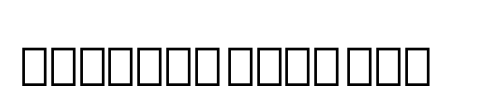

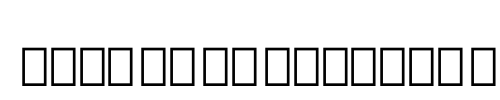

In [8]:
from IPython.display import Image as IPImage, display

display(IPImage(os.path.join(synthetic_path, 'urdu_1.png')))
display(IPImage(os.path.join(synthetic_path, 'urdu_10.png')))

In [9]:
import os
print(os.path.exists('/content/NotoNastaliqUrdu.ttf'))
print(os.path.getsize('/content/NotoNastaliqUrdu.ttf'))

True
690304
